In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# reading data

words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [3]:
# Mapping fuctions

chars = sorted(set(list(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
sorted(stoi.items(), key=lambda x: x[1])

itos = {i:s for s,i in stoi.items()}

print(stoi)     #Encoding Function
print(itos)     #Decoding Function

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
# building the dataset

block_size = 3
X, Y = [], []

for w in words:
    # print(w)

    context = [0]*block_size
    for ch in w+'.':
        X.append(context)
        ix = stoi[ch]
        Y.append(ix)

        # print(''.join(itos[i] for i in context),'------>',itos[ix],'Encoded as: ', ix)
        context = context[1:] + [ix]


In [5]:
# typecasting to tensors

X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([228146, 3]), torch.Size([228146]), torch.int64, torch.int64)

In [6]:
C = torch.randn((27,2), generator=torch.Generator().manual_seed(2147483647))

emb = C[X]

emb.shape

torch.Size([228146, 3, 2])

In [7]:
# F.one_hot(torch.tensor([5]), num_classes=27).float() @ C
# One hot multiplication table that yeild the same result with much more computing power so we will stick to the embedding table C method

In [8]:
# Layers of the neural network

w1 = torch.randn((6,100), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
# w2 = torch.randn((100,27), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)

b1 = torch.randn(100, generator=torch.Generator().manual_seed(2147483647), requires_grad=True)

# emb @ w1 + b1     <--- Will not work
emb[:5]

tensor([[[ 1.5674, -0.2373],
         [ 1.5674, -0.2373],
         [ 1.5674, -0.2373]],

        [[ 1.5674, -0.2373],
         [ 1.5674, -0.2373],
         [-0.4713,  0.7868]],

        [[ 1.5674, -0.2373],
         [-0.4713,  0.7868],
         [ 2.4448, -0.6701]],

        [[-0.4713,  0.7868],
         [ 2.4448, -0.6701],
         [ 2.4448, -0.6701]],

        [[ 2.4448, -0.6701],
         [ 2.4448, -0.6701],
         [-0.0274, -1.1008]]])

In [9]:
# L1 = torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], dim=1)

# torch.cat(torch.unbind(emb, dim=1), 1) == emb.view(32, -1)

L1 = emb.view(-1, 6)

L1[:10]

tensor([[ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.4713,  0.7868],
        [ 1.5674, -0.2373, -0.4713,  0.7868,  2.4448, -0.6701],
        [-0.4713,  0.7868,  2.4448, -0.6701,  2.4448, -0.6701],
        [ 2.4448, -0.6701,  2.4448, -0.6701, -0.0274, -1.1008],
        [ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -1.0725,  0.7276],
        [ 1.5674, -0.2373, -1.0725,  0.7276, -0.0707,  2.4968],
        [-1.0725,  0.7276, -0.0707,  2.4968,  0.6772, -0.8404],
        [-0.0707,  2.4968,  0.6772, -0.8404, -0.1158, -1.2078]])

In [10]:
O1 = L1 @ w1 + b1

O1

tensor([[ 5.3505,  3.3582,  1.5654,  ..., -6.7018,  1.0578, -1.5421],
        [ 6.7181,  1.8316,  2.6802,  ..., -3.0416,  0.3827, -4.6860],
        [ 0.9439,  2.0122, -2.1327,  ..., -4.0324, -0.1984,  3.4235],
        ...,
        [ 3.0697, -2.0054,  0.3856,  ...,  2.3059, -0.2722, -3.1081],
        [-0.0440, -2.4048, -2.0202,  ...,  0.3586,  0.9504,  1.6338],
        [-0.0770,  0.5841,  0.9861,  ...,  0.8657,  3.3953, -2.3673]],
       grad_fn=<AddBackward0>)

In [11]:
K1 = torch.tanh(O1)

K1

tensor([[ 1.0000,  0.9976,  0.9163,  ..., -1.0000,  0.7848, -0.9125],
        [ 1.0000,  0.9500,  0.9906,  ..., -0.9954,  0.3651, -0.9998],
        [ 0.7370,  0.9649, -0.9723,  ..., -0.9994, -0.1958,  0.9979],
        ...,
        [ 0.9957, -0.9644,  0.3675,  ...,  0.9803, -0.2657, -0.9960],
        [-0.0440, -0.9838, -0.9654,  ...,  0.3440,  0.7400,  0.9266],
        [-0.0768,  0.5257,  0.7557,  ...,  0.6992,  0.9978, -0.9826]],
       grad_fn=<TanhBackward0>)

In [12]:
# Layer 2

w2 = torch.randn((100,27), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
b2 = torch.randn(27, generator=torch.Generator().manual_seed(2147483647), requires_grad=True)

O2 = K1 @ w2 + b2

O2.shape

torch.Size([228146, 27])

In [13]:
# Softmax

counts = O2.exp()
probs = counts / counts.sum(1, keepdim=True)

probs.shape

torch.Size([228146, 27])

In [14]:
probs[7].sum()

tensor(1.0000, grad_fn=<SumBackward0>)

In [15]:
# Loss function

# loss = -probs[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(O2, Y)

# loss
# probs[torch.arange(32), Y].shape
loss


tensor(16.9036, grad_fn=<NllLossBackward0>)

In [16]:
# # Backpropagation
# for p in [L1, w1, b1, w2, b2]:
#     p.grad = None
# loss.backward()

# # Updation

# for p in parameters:
#     p.data += -0.1 * p.grad


# Will not work because L1 is not a parameter but an intermediate result of the forward pass. We will need to recompute the forward pass in each iteration of the training loop.

In [17]:
plt.plot(log_epochr, lossi)

NameError: name 'log_epochr' is not defined

<h1> Making as per the train, validation and test split </h1>

In [18]:
# Build a dataset

def build_dataset(words):
    block_size = 5
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            X.append(context)
            ix = stoi[ch]
            Y.append(ix)

            context = context[1:] + [ix]

    # print(f"X {X.shape}, Y {Y.shape}")

    return torch.tensor(X), torch.tensor(Y)


import random

random.seed(2147483647)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

n1, n2, len(words)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [19]:
# Combining all the steps together in a training loop

hidden_layer_size = 200
dimensions = 10
block_size = 5

C = torch.randn((27,dimensions), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
w1 = torch.randn((dimensions*block_size,hidden_layer_size), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
b1 = torch.randn(hidden_layer_size, generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
w2 = torch.randn((hidden_layer_size,27), generator=torch.Generator().manual_seed(2147483647), requires_grad=True)
b2 = torch.randn(27, generator=torch.Generator().manual_seed(2147483647), requires_grad=True)

parameters = [C, w1, b1, w2, b2]

In [20]:
sum(p.nelement() for p in parameters)

15897

In [21]:
lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre

In [22]:
epochs = 100000
log_epochr = []
epochr = []
lossi = []

for i in range(epochs):

    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    L1 = emb.view(-1, 50)
    O1 = L1 @ w1 + b1
    K1 = torch.tanh(O1)
    O2 = K1 @ w2 + b2

    loss = F.cross_entropy(O2, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01 if i < 10000 else 0.001
    for p in parameters:
        # p.data += -lr * p.grad
        p.data += -lr * p.grad

    # track stats
    log_epochr.append(torch.log10(torch.tensor(i) + 1))
    epochr.append(i)
    lossi.append(loss.item())

print(loss.item())


/home/shaurya/Documents/zth_ak/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


2.5557169914245605


In [23]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 50) @ w1 + b1)
o = h @ w2 + b2
loss = F.cross_entropy(o, Ytr)
print(loss.item())

2.515458345413208


In [24]:
# Evaluate

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 50) @ w1 + b1)
o = h @ w2 + b2
loss = F.cross_entropy(o, Ydev)
print(loss.item())

2.534475326538086


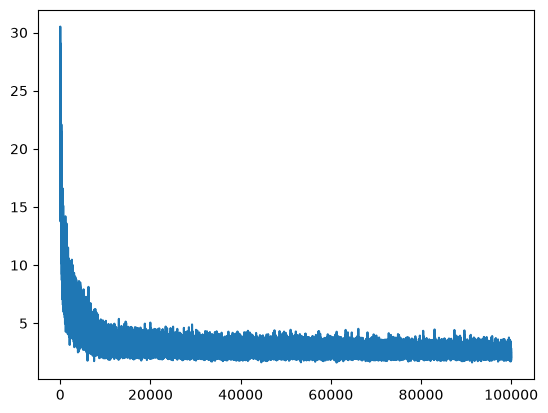

In [25]:
plt.plot(epochr, lossi)


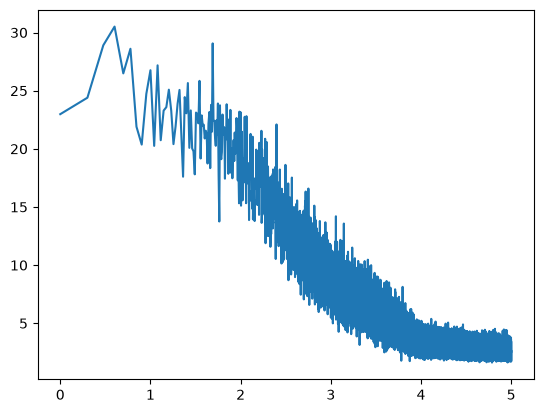

In [26]:
plt.plot(log_epochr, lossi)

In [27]:
# Sampling from the model

g = torch.Generator().manual_seed(random.randint(0, 2147483647))

for _ in range(10):
    out = []
    context = [0]*block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 50) @ w1 + b1)
        o = h @ w2 + b2
        probs = F.softmax(o, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

admio.
jasoi.
maylsloy.
emins.
teymin.
deysiiee.
kaveo.
alosenari.
nrtayn.
samaliysk.
